# Pomeranian Actuarial Climate Index: reproducible workflow

This notebook follows the lecture *Developing an Actuarial Climate Index: A Case Study of the Pomeranian Region* (`lectures/pomeranian_ACI_implementation.pdf`). It uses the Python rIACI port in `python_iaci`.

**Scope.** Build the regional daily weather series, calculate the monthly land components, construct and standardise the regional sea-level series, and assemble the full six-component PomACI.

**External inputs:** ERA5-Land hourly data, PSMSL monthly RLR files for stations 64 and 645, and one monthly Copernicus Marine `sla` NetCDF file.

**Case conventions:** bounding box (north, west, south, east) = (54.88, 16.71, 53.46, 19.63); reference years 1961–1991; temperature threshold window `n = 5`; monthly missing-day limit = 3; annual limit = 15.


In [9]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "python_iaci" / "iaci").exists():
    raise RuntimeError("Open this notebook with the LSNA project folder as the working directory.")
sys.path.insert(0, str(PROJECT_ROOT / "python_iaci"))

from iaci import (
    climate_input, tx90p, tx10p, tn90p, tn10p, rx5day, w90p,
    t90p_std, t10p_std, rx5day_std, w90p_std,
    calculate_standardized, merge_components, download_data,
)

DATA_DIR = PROJECT_ROOT / "data" / "pomerania"
OUTPUT_DIR = PROJECT_ROOT / "output" / "pomerania"
RAW_NC_DIR = DATA_DIR / "cds_data_pomerania"
ARCO_NC_DIR = DATA_DIR / "arco_data_pomerania"
PROCESSED_DIR = DATA_DIR / "processed"
GRID_CSV_DIR = DATA_DIR / "grid_csv"
SELECTED_CELLS_CSV = DATA_DIR / "pomerania_selected_grid_cells.csv"
REGIONAL_DAILY_CSV = DATA_DIR / "pomerania_regional_daily_climate.csv"
PSMSL_GDANSK_FILE = DATA_DIR / "64.rlrdata.txt"
PSMSL_WLADYSLAWOWO_FILE = DATA_DIR / "645.rlrdata.txt"
COPERNICUS_PATTERN = "cmems_mod_bal_phy_my_P1M-m*.nc"

BASE_RANGE = (1961, 1991)
AREA_POMERANIA = (54.88, 16.71, 53.46, 19.63)
TEMP_WINDOW_DAYS = 5
CLIMATE_COLUMNS = ["TMAX", "TMIN", "PRCP", "WP"]
EXPECTED_MONTHS = pd.period_range("1961-01", "2026-04", freq="M")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
print("Project:", PROJECT_ROOT)
print("Expected ERA5-Land months:", len(EXPECTED_MONTHS))


Project: c:\Users\mlata\Documents\sci\EKONOMIA\aktuariat\LSNA
Expected ERA5-Land months: 784


## 1. Obtain ERA5-Land data

Choose one download method. The processing in section 2 uses the ARCO files.


### 1.1 Original monthly CDS method

Python port of the rIACI download method: one CDS request per month, organised in ten-year runs.


In [1]:
RUN_ORIGINAL_DOWNLOAD = False  # Set True to use the original monthly CDS method.

if RUN_ORIGINAL_DOWNLOAD:
    import cdsapi
    from getpass import getpass

    cds_client = cdsapi.Client(
        url="https://cds.climate.copernicus.eu/api",
        key=getpass("CDS API token (hidden): "),
    )
    ORIGINAL_DECADES = [
        (1961, 1970), (1971, 1980), (1981, 1990),
        (1991, 2000), (2001, 2010), (2011, 2020),
        (2021, 2025),
    ]
    for first_year, last_year in ORIGINAL_DECADES:
        download_data(
            first_year, last_year,
            area=AREA_POMERANIA,
            output_dir=RAW_NC_DIR,
            client=cds_client,
        )
    download_data(
        2026, 2026, start_month=1, end_month=4,
        area=AREA_POMERANIA,
        output_dir=RAW_NC_DIR,
        client=cds_client,
    )


### 1.2 ARCO download

Reads the same four variables in ten-year blocks. The final block includes May 1, 2026 so April 30 precipitation is complete. Requires `xarray`, `dask`, `zarr`, `fsspec`, `aiohttp`, and `netCDF4` in the notebook environment.


In [11]:
RUN_ARCO_DOWNLOAD = False  # Set True to download the full ARCO history.

if RUN_ARCO_DOWNLOAD:
    import os
    from getpass import getpass
    from time import perf_counter
    import xarray as xr

    token = os.environ.get("CDS_API_KEY") or getpass("CDS API token (hidden): ")
    ARCO_NC_DIR.mkdir(parents=True, exist_ok=True)

    # Each tuple contains a cloud store and the variables read from it.
    stores = [
        (
            "https://arco.datastores.ecmwf.int/cadl-arco-geo-007/arco/reanalysis_era5_land/sfc-2m-temperature/geoChunked.zarr",
            ["t2m"],
        ),
        (
            "https://arco.datastores.ecmwf.int/cadl-arco-geo-009/arco/reanalysis_era5_land/sfc-pressure-precipitation/geoChunked.zarr",
            ["tp"],
        ),
        (
            "https://arco.datastores.ecmwf.int/cadl-arco-geo-008/arco/reanalysis_era5_land/sfc-wind/geoChunked.zarr",
            ["u10", "v10"],
        ),
    ]
    decades = [
        # (1961, 1970), (1971, 1980), (1981, 1990),
        # (1991, 2000), 
        (2001, 2010), (2011, 2020),
        (2021, 2026),
    ]
    north, west, south, east = (round(value, 1) for value in AREA_POMERANIA)

    for first_year, last_year in decades:
        final_day = "2026-05-01" if last_year == 2026 else f"{last_year}-12-31"
        selection = {
            "time": slice(f"{first_year}-01-01T00:00", f"{final_day}T23:00"),
            "latitude": slice(south - 0.05, north + 0.05),
            "longitude": slice(west - 0.05, east + 0.05),
        }
        opened = []
        started = perf_counter()
        try:
            groups = []
            for url, variables in stores:
                source = xr.open_zarr(
                    url,
                    consolidated=True,
                    storage_options={"headers": {"Authorization": f"Bearer {token}"}},
                )
                opened.append(source)
                groups.append(source[variables].sel(**selection))

            decade = xr.merge(groups, join="exact")
            output_file = ARCO_NC_DIR / f"{first_year}_{last_year}_arco.nc"
            decade.to_netcdf(output_file)
            print(f"Saved {output_file.name}: {output_file.stat().st_size / 1_000_000:.1f} MB "
                  f"in {(perf_counter() - started) / 60:.2f} minutes")
        finally:
            for source in opened:
                source.close()


## 2. Convert hourly ARCO data to daily grid-point series

After all ARCO blocks are complete, set `RUN_NETCDF_PROCESSING = True` in the next cell. It combines the non-overlapping blocks and derives daily TMAX, TMIN, PRCP, and WP for each grid point. ARCO precipitation is an hourly amount stamped at the end of its hour. The processor shifts those stamps back one hour before summing and requires all 24 hours for each daily value. Do not mix files from the older CDS route into the ARCO folder: its precipitation has a different accumulation convention.

**Your action if processing elsewhere:** place one CSV per grid point in the `grid_csv` folder, named latitude_longitude.csv (for example `54.0_18.5.csv`). Each CSV needs columns `time`, `TMAX`, `TMIN`, `PRCP`, and `WP`.


In [12]:
RUN_NETCDF_PROCESSING = False  # Set True after the ARCO download finishes.

if RUN_NETCDF_PROCESSING:
    from iaci.netcdf_io import process_data, export_data_to_csv

    PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
    GRID_CSV_DIR.mkdir(parents=True, exist_ok=True)
    process_data(str(ARCO_NC_DIR), str(PROCESSED_DIR), save_merged=False)
    export_data_to_csv(
        str(PROCESSED_DIR / "processed_data.nc"),
        str(GRID_CSV_DIR),
    )

grid_files = sorted(GRID_CSV_DIR.glob("*.csv")) if GRID_CSV_DIR.exists() else []
print("Daily grid-cell CSV files:", len(grid_files))
print("First files:", [p.name for p in grid_files[:5]])


Daily grid-cell CSV files: 342
First files: ['53.5_16.7.csv', '53.5_16.8.csv', '53.5_16.9.csv', '53.5_17.0.csv', '53.5_17.1.csv']


## 3. Select grid centres inside Pomorskie

Use the fixed Eurostat GISCO NUTS 2024 boundary for Pomorskie (`PL63`) and retain grid centres strictly inside it. The cell saves the selected coordinates and a diagnostic map. Install the dependencies from `requirements-pomeranian-v2.txt` once if GeoPandas is unavailable.


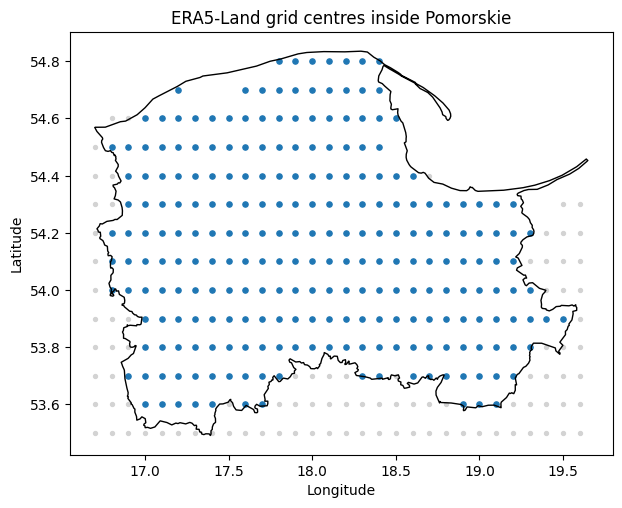

Selected 248 of 342 grid centres
Coordinates: c:\Users\mlata\Documents\sci\EKONOMIA\aktuariat\LSNA\data\pomerania\pomerania_selected_grid_cells.csv
Map: c:\Users\mlata\Documents\sci\EKONOMIA\aktuariat\LSNA\output\pomerania\pomerania_selected_grid_cells.png


In [13]:
import geopandas as gpd
import matplotlib.pyplot as plt

POMORSKIE_BOUNDARY_URL = (
    "https://gisco-services.ec.europa.eu/distribution/v2/nuts/distribution/"
    "PL63-region-01m-4326-2024.geojson"
)
SELECTION_MAP = OUTPUT_DIR / "pomerania_selected_grid_cells.png"

pomorskie = gpd.read_file(POMORSKIE_BOUNDARY_URL).to_crs("EPSG:4326")

coordinates = [tuple(map(float, path.stem.split("_"))) for path in grid_files]
candidates = pd.DataFrame(coordinates, columns=["latitude", "longitude"]).drop_duplicates()
points = gpd.GeoDataFrame(
    candidates,
    geometry=gpd.points_from_xy(candidates["longitude"], candidates["latitude"]),
    crs="EPSG:4326",
)

inside = points.within(pomorskie.geometry.union_all())
selected_cells = (
    points.loc[inside, ["latitude", "longitude"]]
    .sort_values(["latitude", "longitude"])
    .reset_index(drop=True)
)
selected_cells.to_csv(SELECTED_CELLS_CSV, index=False)

fig, ax = plt.subplots(figsize=(7, 7))
pomorskie.boundary.plot(ax=ax, color="black", linewidth=1)
points.plot(ax=ax, color="lightgrey", markersize=8)
points.loc[inside].plot(ax=ax, color="tab:blue", markersize=14)
ax.set(title="ERA5-Land grid centres inside Pomorskie", xlabel="Longitude", ylabel="Latitude")
fig.savefig(SELECTION_MAP, dpi=160, bbox_inches="tight")
plt.show()

print(f"Selected {len(selected_cells)} of {len(points)} grid centres")
print("Coordinates:", SELECTED_CELLS_CSV)
print("Map:", SELECTION_MAP)


## 4. Form one regional daily climate series

For each day, average TMAX, TMIN, PRCP and WP over the selected cells. This is a spatial average of cell-level daily quantities; it is **not** a daily maximum/minimum taken after averaging hourly temperatures across the region (lecture slide 52).

You may instead provide pomerania_regional_daily_climate.csv with date, TMAX, TMIN, PRCP and WP. The code checks that every selected cell has a file and reports daily spatial coverage.


In [14]:
def aggregate_selected_cells(selected_cells, grid_csv_dir, calendar):
    totals = pd.DataFrame(0.0, index=calendar, columns=CLIMATE_COLUMNS)
    counts = pd.DataFrame(0, index=calendar, columns=CLIMATE_COLUMNS)
    paths = []
    for row in selected_cells.itertuples(index=False):
        name = f"{row.latitude:.1f}_{row.longitude:.1f}.csv"
        paths.append(grid_csv_dir / name)
    missing_files = [path.name for path in paths if not path.exists()]
    if missing_files:
        raise FileNotFoundError(f"Missing {len(missing_files)} selected-cell CSVs: {missing_files[:10]}")

    for path in paths:
        cell = pd.read_csv(path, usecols=["time", *CLIMATE_COLUMNS])
        cell["time"] = pd.to_datetime(cell["time"], errors="raise").dt.normalize()
        if cell["time"].duplicated().any():
            raise ValueError(f"Duplicate dates in {path.name}.")
        cell = cell.set_index("time")[CLIMATE_COLUMNS].reindex(calendar)
        for column in CLIMATE_COLUMNS:
            values = pd.to_numeric(cell[column], errors="coerce")
            totals[column] += values.fillna(0).to_numpy()
            counts[column] += values.notna().to_numpy(dtype=int)
    regional = totals.div(counts.where(counts.ne(0)))
    regional.index.name = "date"
    coverage = counts / len(paths)
    return regional.reset_index(), coverage

if REGIONAL_DAILY_CSV.exists():
    regional_daily = pd.read_csv(REGIONAL_DAILY_CSV)
    coverage = None
    print("Using externally prepared regional daily series:", REGIONAL_DAILY_CSV)
else:
    if selected_cells is None:
        raise FileNotFoundError(
            "Provide pomerania_regional_daily_climate.csv or first create the selected-cell CSV."
        )
    calendar = pd.date_range("1961-01-01", "2026-04-30", freq="D")
    regional_daily, coverage = aggregate_selected_cells(selected_cells, GRID_CSV_DIR, calendar)
    REGIONAL_DAILY_CSV.parent.mkdir(parents=True, exist_ok=True)
    regional_daily.to_csv(REGIONAL_DAILY_CSV, index=False)
    print("Saved regional daily series:", REGIONAL_DAILY_CSV)

required = {"date", *CLIMATE_COLUMNS}
if not required.issubset(regional_daily.columns):
    raise ValueError(f"Regional daily CSV needs columns {sorted(required)}.")
print(regional_daily.head())


Using externally prepared regional daily series: c:\Users\mlata\Documents\sci\EKONOMIA\aktuariat\LSNA\data\pomerania\pomerania_regional_daily_climate.csv
         date      TMAX      TMIN      PRCP          WP
0  1961-01-01  0.956675 -2.026522  1.130475   11.617357
1  1961-01-02  0.733340 -0.914821  0.351382   27.304542
2  1961-01-03  1.510978 -1.320994  1.712869  100.949872
3  1961-01-04  4.131604  0.236151  2.960072   30.219329
4  1961-01-05  1.580599 -1.539164  0.328395   23.617714


In [15]:
regional_daily["date"] = pd.to_datetime(regional_daily["date"], errors="raise")
regional_daily = regional_daily.sort_values("date").reset_index(drop=True)
if regional_daily["date"].duplicated().any():
    raise ValueError("Regional daily series contains duplicate dates.")
print("First and last dates:", regional_daily["date"].min(), regional_daily["date"].max())
print("Missing daily values by variable:")
print(regional_daily[CLIMATE_COLUMNS].isna().sum())
print("Annual precipitation totals (mm), first years:")
print(regional_daily.groupby(regional_daily["date"].dt.year)["PRCP"].sum(min_count=1).head())
if coverage is not None:
    print("Minimum cell coverage by variable:")
    print(coverage.min())


First and last dates: 1961-01-01 00:00:00 2026-04-30 00:00:00
Missing daily values by variable:
TMAX    0
TMIN    0
PRCP    0
WP      0
dtype: int64
Annual precipitation totals (mm), first years:
date
1961    729.576650
1962    809.868862
1963    725.656654
1964    535.256691
1965    767.851274
Name: PRCP, dtype: float64


## 5. Build the climate input and raw components

The same reference years, daily series and missing-day limits feed every component. The Python port's n controls the temperature running-quantile window. Rx5day remains a fixed five-day precipitation index. Slide 56 describes n as if it controls Rx5day; the downloaded rIACI source uses n for temperature thresholds, so the code follows that actual implementation.

The wind input is the daily WP proxy from the processing stage. The port retains rIACI's wind threshold calculation. Sources: lecture slides 53–79.


In [ ]:
ci = climate_input(
    dates=regional_daily["date"],
    tmax=regional_daily["TMAX"],
    tmin=regional_daily["TMIN"],
    prec=regional_daily["PRCP"],
    wind=regional_daily["WP"],
    base_range=BASE_RANGE,
    n=TEMP_WINDOW_DAYS,
    temp_quantiles=(0.10, 0.90),
    wind_quantile=0.90,
    max_missing_days={"annual": 15, "monthly": 3},
)
print("Aligned daily dates:", len(ci.dates), ci.dates.min(), ci.dates.max())
print("Temperature threshold rows:", len(ci.quantiles["tmax"]))
print("Invalid monthly periods per variable:")
for variable, mask in ci.na_masks["monthly"].items():
    print(variable, int(mask.isna().sum()))


Aligned daily dates: 23861 1961-01-01 00:00:00 2026-04-30 00:00:00
Temperature threshold rows: 366
Invalid monthly periods per variable:
tmax 0
tmin 0
prec 0
wind 0


In [17]:
raw_components = {
    "TX90p": tx90p(ci),
    "TN90p": tn90p(ci),
    "TX10p": tx10p(ci),
    "TN10p": tn10p(ci),
    "Rx5day": rx5day(ci),
    "W90p": w90p(ci),
}
for name, frame in raw_components.items():
    frame.to_csv(OUTPUT_DIR / f"pomerania_raw_{name}.csv", index=False)
print({name: len(frame) for name, frame in raw_components.items()})


{'TX90p': 784, 'TN90p': 784, 'TX10p': 784, 'TN10p': 784, 'Rx5day': 784, 'W90p': 784}


## 6. Pomeranian monthly CDD proportion

**Case-specific formula.** A dry day has PRCP < 1 mm. Within each calendar month, find the longest consecutive dry spell and divide its length by that month's number of days. Missing precipitation breaks a spell; months with more than three missing days are masked. This follows lecture slides 70–71.

This differs from the inherited rIACI cdd_std function, which interpolates an annual maximum to monthly values. The notebook therefore implements the Pomeranian definition explicitly.


In [18]:
def pomeranian_monthly_cdd_proportion(climate):
    precipitation = climate.data["prec"]
    labels = climate.dates.strftime("%Y-%m")
    rows = []
    for month, group in precipitation.groupby(labels, sort=True):
        longest = current = 0
        for value in group.to_numpy(dtype=float):
            if np.isfinite(value) and value < 1.0:
                current += 1
                longest = max(longest, current)
            else:
                current = 0
        proportion = longest / len(group)
        if pd.isna(climate.na_masks["monthly"]["prec"].loc[month]):
            proportion = np.nan
        rows.append({"Date": month, "Value": proportion})
    return pd.DataFrame(rows)

raw_components["CDD_proportion"] = pomeranian_monthly_cdd_proportion(ci)
raw_components["CDD_proportion"].to_csv(
    OUTPUT_DIR / "pomerania_raw_CDD_proportion.csv", index=False
)
print(raw_components["CDD_proportion"].head())


      Date     Value
0  1961-01  0.516129
1  1961-02  0.535714
2  1961-03  0.322581
3  1961-04  0.266667
4  1961-05  0.225806


## 7. Standardise the five land components and combine by date

All standardisation uses 1961–1991. The cold component enters with a minus sign. The temperature, Rx5day and W90p functions use the translated rIACI formulas; monthly CDD is standardised from the Pomeranian proportion above.

The five-component average below is a **provisional land-only diagnostic**, not the final PomACI. The final definition has six terms including sea level (lecture slides 100–102).


In [20]:
def standardised_land_components(climate):
    cdd_raw = pomeranian_monthly_cdd_proportion(climate)
    return {
        "T90p": t90p_std(climate, "monthly"),
        "T10p": t10p_std(climate, "monthly"),
        "Rx5day": rx5day_std(climate, "monthly"),
        "CDD": calculate_standardized(cdd_raw, "monthly", BASE_RANGE),
        "W90p": w90p_std(climate, "monthly"),
    }

land_components = standardised_land_components(ci)
land_wide = merge_components(land_components)
land_wide["T10p_oriented"] = -land_wide["T10p"]
land_wide["PomACI_land5"] = (
    land_wide["T90p"] + land_wide["T10p_oriented"]
    + land_wide["Rx5day"] + land_wide["CDD"] + land_wide["W90p"]
) / 5
land_wide.to_csv(OUTPUT_DIR / "pomerania_land_components_monthly.csv", index=False)
print(land_wide.head())
print("Months with all five land components:", int(land_wide["PomACI_land5"].notna().sum()))


      Date      T90p      T10p    Rx5day       CDD      W90p  T10p_oriented  \
0  1961-01 -0.539441 -0.006635 -0.994833  1.423636 -0.441863       0.006635   
1  1961-02  1.066916 -0.684376  0.896804  1.886662 -0.961387       0.684376   
2  1961-03  1.323846 -0.736798  1.404195  0.316522  2.649563       0.736798   
3  1961-04  0.795517 -0.602753 -0.151016  0.066052 -1.063967       0.602753   
4  1961-05 -1.033568 -0.123943  1.616740 -0.174090 -0.649880       0.123943   

   PomACI_land5  
0     -0.109173  
1      0.714674  
2      1.286185  
3      0.049868  
4     -0.023371  
Months with all five land components: 784


## 8. Build the sea-level component and full PomACI

The sea component is one regional monthly series. PSMSL supplies 1961–1999. Copernicus Marine supplies 2000 onward after twelve calendar-month offsets are estimated from the 1993–1999 overlap. The harmonised series is then standardised separately for each calendar month against 1961–1991.


### 8.1 PSMSL regional tide-gauge series

Read the two monthly RLR files, convert their decimal dates, and average the available stations for every month.


In [21]:
def read_psmsl_monthly(path, value_name):
    columns = ["decimal_year", "sea_level_mm", "missing_days", "flag"]
    frame = pd.read_csv(path, sep=";", header=None, names=columns, skipinitialspace=True)

    year = np.floor(frame["decimal_year"]).astype(int)
    month = np.rint((frame["decimal_year"] - year) * 12 + 0.5).astype(int)
    dates = pd.to_datetime({"year": year, "month": month, "day": 1})

    values = pd.to_numeric(frame["sea_level_mm"], errors="coerce").replace(-99999, np.nan)
    return pd.DataFrame({
        "Date": dates.dt.to_period("M").astype(str),
        value_name: values,
    })


gdansk = read_psmsl_monthly(PSMSL_GDANSK_FILE, "Gdansk_mm")
wladyslawowo = read_psmsl_monthly(PSMSL_WLADYSLAWOWO_FILE, "Wladyslawowo_mm")

psmsl_regional = gdansk.merge(wladyslawowo, on="Date", how="outer", validate="one_to_one")
station_columns = ["Gdansk_mm", "Wladyslawowo_mm"]
psmsl_regional["stations_available"] = psmsl_regional[station_columns].notna().sum(axis=1)
psmsl_regional["Value"] = psmsl_regional[station_columns].mean(axis=1, skipna=True)
psmsl_regional = psmsl_regional.loc[
    psmsl_regional["Date"].between("1961-01", "1999-12")
].sort_values("Date").reset_index(drop=True)

psmsl_regional.to_csv(OUTPUT_DIR / "pomerania_psmsl_regional_monthly.csv", index=False)
print("PSMSL months:", len(psmsl_regional))
print("Months with two stations:", int(psmsl_regional["stations_available"].eq(2).sum()))


PSMSL months: 468
Months with two stations: 468


### 8.2 Copernicus Marine regional series

Average `sla` over every valid marine cell in the downloaded box and convert metres to millimetres.


In [22]:
import xarray as xr


def read_copernicus_regional_sla(path):
    with xr.open_dataset(path) as dataset:
        sla = dataset["sla"]
        spatial_dimensions = [dimension for dimension in sla.dims if dimension != "time"]
        cell_count = sla.notnull().sum(dim=spatial_dimensions).load()
        regional = sla.mean(dim=spatial_dimensions, skipna=True).load()
        units = str(sla.attrs.get("units", "")).strip().lower()

    if units in {"m", "metre", "metres", "meter", "meters"}:
        regional = regional * 1000
    elif units not in {"mm", "millimetre", "millimetres", "millimeter", "millimeters"}:
        raise ValueError(f"Unsupported Copernicus sea-level unit: {units!r}")

    dates = pd.to_datetime(regional["time"].values).to_period("M").astype(str)
    frame = pd.DataFrame({
        "Date": dates,
        "Value": regional.values.astype(float),
        "marine_cells": cell_count.values.astype(int),
    })
    return frame


copernicus_files = sorted(DATA_DIR.glob(COPERNICUS_PATTERN))
if len(copernicus_files) != 1:
    raise FileNotFoundError(
        f"Expected one Copernicus file matching {COPERNICUS_PATTERN!r}; found {len(copernicus_files)}."
    )

COPERNICUS_NC = copernicus_files[0]
copernicus_regional = read_copernicus_regional_sla(COPERNICUS_NC)
copernicus_regional.to_csv(
    OUTPUT_DIR / "pomerania_copernicus_sla_regional_monthly.csv", index=False
)

print("Copernicus period:", copernicus_regional["Date"].iloc[0], "to", copernicus_regional["Date"].iloc[-1])
print(
    "Valid marine cells per month:",
    int(copernicus_regional["marine_cells"].min()),
    "to",
    int(copernicus_regional["marine_cells"].max()),
)


Copernicus period: 1993-01 to 2026-05
Valid marine cells per month: 5983 to 5983


### 8.3 Calibrate and splice the two sources

For each calendar month, calculate the mean `PSMSL − Copernicus` difference over 1993–1999. Add that offset to every Copernicus observation, then splice at January 2000.


In [23]:
def harmonise_sea_level(psmsl, copernicus):
    psmsl_values = psmsl[["Date", "Value"]].rename(columns={"Value": "PSMSL_mm"})
    copernicus_values = copernicus[["Date", "Value"]].rename(
        columns={"Value": "Copernicus_mm"}
    )

    overlap = psmsl_values.merge(copernicus_values, on="Date", validate="one_to_one")
    overlap = overlap.loc[overlap["Date"].between("1993-01", "1999-12")].copy()
    overlap["month"] = overlap["Date"].str.slice(5, 7).astype(int)
    overlap["difference_mm"] = overlap["PSMSL_mm"] - overlap["Copernicus_mm"]

    offsets = overlap.groupby("month", sort=True)["difference_mm"].mean().reindex(range(1, 13))
    if offsets.isna().any():
        raise ValueError("The 1993–1999 overlap does not contain all twelve calendar months.")

    adjusted = copernicus_values.copy()
    adjusted["month"] = adjusted["Date"].str.slice(5, 7).astype(int)
    adjusted["offset_mm"] = adjusted["month"].map(offsets)
    adjusted["Value"] = adjusted["Copernicus_mm"] + adjusted["offset_mm"]

    historical = psmsl_values.loc[psmsl_values["Date"].le("1999-12")].copy()
    historical["Value"] = historical["PSMSL_mm"]
    historical["source"] = "PSMSL"

    continuation = adjusted.loc[adjusted["Date"].ge("2000-01")].copy()
    continuation["source"] = "Copernicus adjusted"

    harmonised = pd.concat([
        historical[["Date", "Value", "source"]],
        continuation[["Date", "Value", "source"]],
    ], ignore_index=True).sort_values("Date").reset_index(drop=True)

    offset_table = offsets.rename("offset_mm").rename_axis("month").reset_index()
    return harmonised, adjusted, offset_table, overlap


sea_harmonised, copernicus_adjusted, sea_offsets, sea_overlap = harmonise_sea_level(
    psmsl_regional, copernicus_regional
)

sea_harmonised.to_csv(OUTPUT_DIR / "pomerania_sea_level_harmonised_monthly.csv", index=False)
copernicus_adjusted.to_csv(OUTPUT_DIR / "pomerania_copernicus_sla_adjusted_monthly.csv", index=False)
sea_offsets.to_csv(OUTPUT_DIR / "pomerania_sea_level_monthly_offsets.csv", index=False)

print("Calibration observations:", len(sea_overlap))
print("Harmonised sea-level period:", sea_harmonised["Date"].iloc[0], "to", sea_harmonised["Date"].iloc[-1])
print(sea_offsets)


Calibration observations: 84
Harmonised sea-level period: 1961-01 to 2026-05
    month    offset_mm
0       1  7075.732791
1       2  7037.604257
2       3  7004.779704
3       4  6984.096586
4       5  6971.535319
5       6  6942.313833
6       7  6926.349798
7       8  6931.976873
8       9  6930.598607
9      10  6921.271181
10     11  6971.491796
11     12  6979.085153


### 8.4 Standardise sea level and calculate the full index

Standardise the harmonised raw series by calendar month against 1961–1991. All six components are joined explicitly by `Date` and receive equal weight.


In [24]:
sea_for_index = land_wide[["Date"]].merge(
    sea_harmonised[["Date", "Value"]], on="Date", how="left", validate="one_to_one"
)
if sea_for_index["Value"].isna().any():
    missing_dates = sea_for_index.loc[sea_for_index["Value"].isna(), "Date"].tolist()
    raise ValueError(f"Sea level is missing for land-component dates: {missing_dates[:5]}")

sea_component = calculate_standardized(sea_for_index, "monthly", BASE_RANGE)
sea_component.to_csv(OUTPUT_DIR / "pomerania_sea_component_monthly.csv", index=False)

full_pomaci = merge_components({**land_components, "Sea": sea_component})
full_pomaci["T10p_oriented"] = -full_pomaci["T10p"]
full_pomaci["PomACI"] = (
    full_pomaci["T90p"] + full_pomaci["T10p_oriented"]
    + full_pomaci["Rx5day"] + full_pomaci["CDD"]
    + full_pomaci["W90p"] + full_pomaci["Sea"]
) / 6
full_pomaci.to_csv(OUTPUT_DIR / "pomerania_full_PomACI_monthly.csv", index=False)

print("Full six-component PomACI months:", len(full_pomaci))
print(full_pomaci[["Date", "Sea", "PomACI"]].head())


Full six-component PomACI months: 784
      Date       Sea    PomACI
0  1961-01 -1.101266 -0.274522
1  1961-02 -0.231104  0.557045
2  1961-03  1.418558  1.308247
3  1961-04  1.238645  0.247997
4  1961-05  1.034006  0.152858


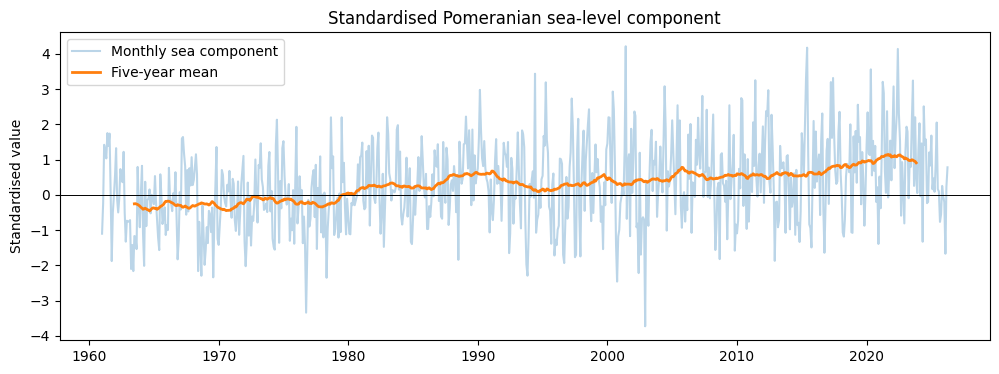

In [25]:
import matplotlib.pyplot as plt

sea_plot = sea_component.copy()
sea_plot["Sea_60m_mean"] = sea_plot["Value"].rolling(60, center=True, min_periods=60).mean()
sea_dates = pd.to_datetime(sea_plot["Date"] + "-01")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(sea_dates, sea_plot["Value"], alpha=0.30, label="Monthly sea component")
ax.plot(sea_dates, sea_plot["Sea_60m_mean"], linewidth=2, label="Five-year mean")
ax.axhline(0, color="black", linewidth=0.7)
ax.set(title="Standardised Pomeranian sea-level component", ylabel="Standardised value")
ax.legend()
plt.show()


## 9. Trend diagnostic and complete seasons

The lecture uses a centred five-year (60-month) moving average for interpretation. Seasonal means use DJF/MAM/JJA/SON; December belongs to the following winter. The function below requires all three monthly values, so the partial first/last winters are not reported (slides 101, 111–113).


In [26]:
def add_five_year_mean(frame, value_column):
    result = frame.copy()
    result[f"{value_column}_60m_mean"] = (
        result[value_column].rolling(60, center=True, min_periods=60).mean()
    )
    return result

def complete_seasonal_means(frame, value_column):
    dates = pd.to_datetime(frame["Date"] + "-01", errors="raise")
    season_lookup = {
        12: "DJF", 1: "DJF", 2: "DJF",
        3: "MAM", 4: "MAM", 5: "MAM",
        6: "JJA", 7: "JJA", 8: "JJA",
        9: "SON", 10: "SON", 11: "SON",
    }
    working = pd.DataFrame({
        "year": dates.dt.year + dates.dt.month.eq(12).astype(int),
        "season": dates.dt.month.map(season_lookup),
        "Value": frame[value_column].to_numpy(dtype=float),
    })
    grouped = working.groupby(["year", "season"], sort=True)["Value"].agg(["mean", "count"])
    grouped = grouped.loc[grouped["count"].eq(3)].reset_index()
    grouped["Date"] = grouped["year"].astype(str) + "-" + grouped["season"]
    return grouped[["Date", "mean"]].rename(columns={"mean": value_column})

land_wide = add_five_year_mean(land_wide, "PomACI_land5")
land_wide.to_csv(OUTPUT_DIR / "pomerania_land_components_monthly.csv", index=False)
land_seasonal = complete_seasonal_means(land_wide, "PomACI_land5")
land_seasonal.to_csv(OUTPUT_DIR / "pomerania_land5_seasonal.csv", index=False)
print("Complete provisional seasons:", len(land_seasonal))

if full_pomaci is not None:
    full_pomaci = add_five_year_mean(full_pomaci, "PomACI")
    full_pomaci.to_csv(OUTPUT_DIR / "pomerania_full_PomACI_monthly.csv", index=False)
    full_seasonal = complete_seasonal_means(full_pomaci, "PomACI")
    full_seasonal.to_csv(OUTPUT_DIR / "pomerania_full_PomACI_seasonal.csv", index=False)
    print("Complete full-PomACI seasons:", len(full_seasonal))


Complete provisional seasons: 260
Complete full-PomACI seasons: 260


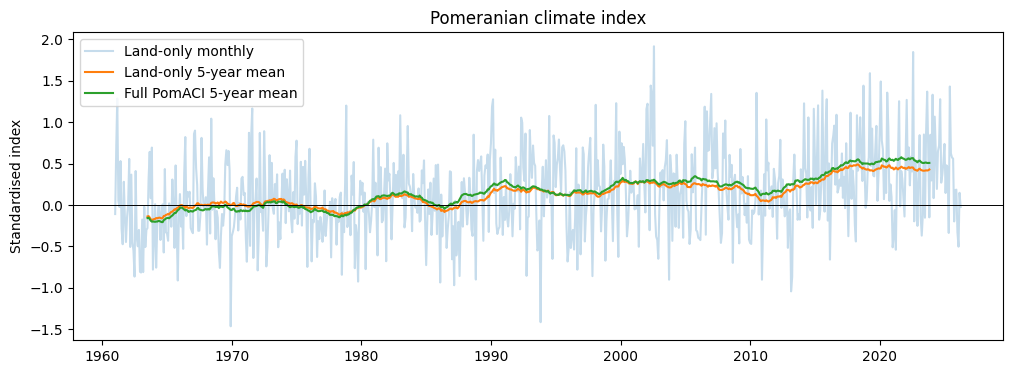

In [27]:
try:
    import matplotlib.pyplot as plt
    monthly_dates = pd.to_datetime(land_wide["Date"] + "-01")
    fig, ax = plt.subplots(figsize=(12, 4))
    ax.plot(monthly_dates, land_wide["PomACI_land5"], alpha=0.25, label="Land-only monthly")
    ax.plot(monthly_dates, land_wide["PomACI_land5_60m_mean"], label="Land-only 5-year mean")
    if full_pomaci is not None:
        ax.plot(monthly_dates, full_pomaci["PomACI_60m_mean"], label="Full PomACI 5-year mean")
    ax.axhline(0, color="black", linewidth=0.7)
    ax.set(title="Pomeranian climate index", ylabel="Standardised index")
    ax.legend()
    plt.show()
except ImportError:
    print("Optional plot skipped: install matplotlib to display the trend.")


## 10. Optional grid-cell extension for seasonal maps

Set `RUN_CELL_LEVEL = True` only when the land grid files need to be rebuilt. The next step adds the same regional sea component to every existing land-grid value:

\[
PomACI_{g,t}=\frac{5\,PomACI^{land5}_{g,t}+Sea_t}{6}.
\]

Sea level therefore shifts every tile equally in a given month; the spatial variation still comes from the five land components.


In [28]:
RUN_CELL_LEVEL = False

if RUN_CELL_LEVEL:
    if selected_cells is None:
        raise FileNotFoundError("Provide the selected-cell CSV first.")
    all_cell_months = []
    all_cell_seasons = []
    for row in selected_cells.itertuples(index=False):
        path = GRID_CSV_DIR / f"{row.latitude:.1f}_{row.longitude:.1f}.csv"
        daily = pd.read_csv(path)
        local_ci = climate_input(
            dates=daily["time"], tmax=daily["TMAX"], tmin=daily["TMIN"],
            prec=daily["PRCP"], wind=daily["WP"],
            base_range=BASE_RANGE, n=TEMP_WINDOW_DAYS,
            max_missing_days={"annual": 15, "monthly": 3},
        )
        local = merge_components(standardised_land_components(local_ci))
        local["PomACI_land5"] = (
            local["T90p"] - local["T10p"] + local["Rx5day"]
            + local["CDD"] + local["W90p"]
        ) / 5
        local["latitude"] = row.latitude
        local["longitude"] = row.longitude
        all_cell_months.append(local[["Date", "latitude", "longitude", "PomACI_land5"]])
        seasonal = complete_seasonal_means(local, "PomACI_land5")
        seasonal["latitude"] = row.latitude
        seasonal["longitude"] = row.longitude
        all_cell_seasons.append(seasonal)
    grid_monthly = pd.concat(all_cell_months, ignore_index=True)
    grid_seasonal = pd.concat(all_cell_seasons, ignore_index=True)
    grid_monthly.to_csv(OUTPUT_DIR / "pomerania_grid_land5_monthly.csv", index=False)
    grid_seasonal.to_csv(OUTPUT_DIR / "pomerania_grid_land5_seasonal.csv", index=False)
    print("Cell-month rows:", len(grid_monthly))
    print("Cell-season rows:", len(grid_seasonal))


In [29]:
import geopandas as gpd
GRID_LAND_MONTHLY_CSV = OUTPUT_DIR / "pomerania_grid_land5_monthly.csv"
GRID_FULL_MONTHLY_CSV = OUTPUT_DIR / "pomerania_grid_PomACI_monthly.csv"
GRID_FULL_SEASONAL_CSV = OUTPUT_DIR / "pomerania_grid_PomACI_seasonal.csv"

grid_land_monthly = pd.read_csv(GRID_LAND_MONTHLY_CSV)
grid_full_monthly = grid_land_monthly.merge(
    sea_component.rename(columns={"Value": "Sea"}),
    on="Date",
    how="inner",
    validate="many_to_one",
)
grid_full_monthly["PomACI"] = (
    5 * grid_full_monthly["PomACI_land5"] + grid_full_monthly["Sea"]
) / 6
grid_full_monthly.to_csv(GRID_FULL_MONTHLY_CSV, index=False)

grid_dates = pd.to_datetime(grid_full_monthly["Date"] + "-01")
season_lookup = {
    12: "DJF", 1: "DJF", 2: "DJF",
    3: "MAM", 4: "MAM", 5: "MAM",
    6: "JJA", 7: "JJA", 8: "JJA",
    9: "SON", 10: "SON", 11: "SON",
}
season_work = grid_full_monthly.assign(
    season_year=grid_dates.dt.year + grid_dates.dt.month.eq(12).astype(int),
    season=grid_dates.dt.month.map(season_lookup),
)
grid_full_seasonal = (
    season_work.groupby(
        ["latitude", "longitude", "season_year", "season"], sort=True
    )["PomACI"]
    .agg(["mean", "count"])
    .reset_index()
)
grid_full_seasonal = grid_full_seasonal.loc[grid_full_seasonal["count"].eq(3)].copy()
grid_full_seasonal["Date"] = (
    grid_full_seasonal["season_year"].astype(str) + "-" + grid_full_seasonal["season"]
)
grid_full_seasonal = grid_full_seasonal[
    ["Date", "latitude", "longitude", "mean"]
].rename(columns={"mean": "PomACI"})
grid_full_seasonal.to_csv(GRID_FULL_SEASONAL_CSV, index=False)

print("Full cell-month rows:", len(grid_full_monthly))
print("Full cell-season rows:", len(grid_full_seasonal))


Full cell-month rows: 194432
Full cell-season rows: 64480


### Map the full grid-cell index

Choose a season stored as `YYYY-DJF`, `YYYY-MAM`, `YYYY-JJA`, or `YYYY-SON`. Negative values are blue and purple, values near zero are green, and high values progress through yellow and orange to dark red.


In [ ]:
from matplotlib.cm import ScalarMappable
from matplotlib.colors import LinearSegmentedColormap, Normalize
from shapely.geometry import box
import geopandas as gpd
import matplotlib.pyplot as plt
def complete_annual_means(monthly, metrics):
    """Calendar-year means, independently masked unless all 12 months exist."""
    dates = pd.to_datetime(monthly["Date"], format="%Y-%m", errors="raise")
    if dates.duplicated().any():
        raise ValueError("Powtórzone miesiące w danych punktowych.")
    values = monthly[metrics].copy()
    values.index = dates
    grouped = values.groupby(values.index.year)
    annual = grouped.mean().where(grouped.count().eq(12)).dropna(how="all")
    annual.insert(0, "Date", annual.index.astype(str) + "-ANN")
    return annual.reset_index(drop=True)


def presentation_scale(values):
    # Exact value/colour anchors from the Pomeranian reference.
    anchors = [(-0.33, "#4828ff"), (-0.25, "#7352bd"), (0.0, "#20c83a"),
               (0.10, "#91ed00"), (0.30, "#ffe000"), (0.55, "#f49a00"), (0.70, "#8b1800")]
    finite = np.asarray(values, dtype=float)
    finite = finite[np.isfinite(finite)]
    low = min(-0.33, float(finite.min())) if finite.size else -0.33
    high = max(0.70, float(finite.max())) if finite.size else 0.70
    if low < anchors[0][0]:
        anchors.insert(0, (low, anchors[0][1]))
    if high > anchors[-1][0]:
        anchors.append((high, anchors[-1][1]))
    return [low, high], [((value-low)/(high-low), colour) for value, colour in anchors]


# Wspólna mapa dla oryginalnego pełnego PomACI oraz wariantu land5.
from IPython.display import display
END = pd.Timestamp("2026-04-30")
METRICS = ["PomACI_land5", "Sea", "PomACI"]
LABELS = ["Indeks land5", "Poziom morza — Sea", "Pełny indeks PomACI"]
map_monthly = pd.read_csv(OUTPUT_DIR / "pomerania_grid_PomACI_monthly.csv")
grid = map_monthly[["latitude", "longitude"]].drop_duplicates()
seasonal_parts, annual_parts = [], []
for (lat, lon), monthly in map_monthly.groupby(["latitude", "longitude"]):
    annual = complete_annual_means(monthly, METRICS)
    annual["latitude"], annual["longitude"] = lat, lon
    annual_parts.append(annual)
    seasonal = None
    for metric in METRICS:
        part = complete_seasonal_means(monthly.reset_index(drop=True), metric)
        seasonal = part if seasonal is None else seasonal.merge(part, on="Date", how="outer", validate="one_to_one")
    seasonal["latitude"], seasonal["longitude"] = lat, lon
    seasonal_parts.append(seasonal)
grid_seasonal = pd.concat(seasonal_parts, ignore_index=True)
grid_annual = pd.concat(annual_parts, ignore_index=True)
grid_periods = pd.concat([grid_seasonal, grid_annual], ignore_index=True)
grid_annual.to_csv(OUTPUT_DIR / "pomerania_grid_components_annual.csv", index=False)
MAP_PERIOD = "1961-MAM"
MAP_VARIABLE = "PomACI"
EXPORT_BENCHMARK_MAPS = False
BENCHMARK_YEARS = [1961,1971,1981,1991,2001,2011,2021,2025]
SEASONS = ["DJF","MAM","JJA","SON"]
MAP_LIMITS, MAP_COLOURS = {}, {}
for metric in METRICS:
    MAP_LIMITS[metric], MAP_COLOURS[metric] = presentation_scale(grid_periods[metric])
STATIC_MAP_DIR = OUTPUT_DIR / "maps_presentation_style"
STATIC_MAP_DIR.mkdir(parents=True,exist_ok=True)

def plot_season_map(period, variable="PomACI", show=True):
    values=grid_periods.loc[grid_periods.Date.eq(period)].dropna(subset=[variable])
    if values.empty:
        print("Brak kompletnego okresu:",period)
        return None
    tiles=gpd.GeoDataFrame(values,geometry=[box(lon-.05,lat-.05,lon+.05,lat+.05)
        for lat,lon in zip(values.latitude,values.longitude)],crs="EPSG:4326")
    low, high = MAP_LIMITS[variable]
    norm=Normalize(vmin=low,vmax=high)
    colour_map=LinearSegmentedColormap.from_list("ACI", MAP_COLOURS[variable], N=65536)
    fig,ax=plt.subplots(figsize=(12,11))
    tiles.plot(ax=ax,column=variable,cmap=colour_map,norm=norm,edgecolor="white",linewidth=.35)
    pomorskie.boundary.plot(ax=ax,color="black",linewidth=1.2)
    for row in values.itertuples():
        ax.text(row.longitude,row.latitude,f"{getattr(row,variable):.1f}",ha="center",va="center",fontsize=5.3,color="black")
    bar=fig.colorbar(ScalarMappable(norm=norm,cmap=colour_map),ax=ax,shrink=.65,pad=.025,aspect=22)
    bar.ax.set_title(variable,fontsize=10,pad=10)
    bar.set_ticks([-0.33, -0.25, 0, 0.10, 0.30, 0.55, 0.70])
    for tick in bar.get_ticks():bar.ax.axhline(tick,color="white",linewidth=.7,alpha=.8)
    ax.set(title=f"Pomorskie — {variable}: {period}",xlabel="Długość geograficzna",ylabel="Szerokość geograficzna")
    fig.tight_layout()
    path=STATIC_MAP_DIR / f"{variable}_{period}.png"
    fig.savefig(path,dpi=180,bbox_inches="tight")
    if show:plt.show()
    plt.close(fig)
    return path

print("Mapa:",plot_season_map(MAP_PERIOD,MAP_VARIABLE))
if EXPORT_BENCHMARK_MAPS:
    generated=[plot_season_map(f"{year}-{season}",show=False) for year in BENCHMARK_YEARS for season in SEASONS + ["ANN"]]
    print("Zapisane mapy porównawcze:",sum(p is not None for p in generated))
# Współrzędne obrysu do mapy interaktywnej.
boundary_x,boundary_y=[],[]
geom=pomorskie.geometry.iloc[0]
for polygon in (list(geom.geoms) if geom.geom_type=="MultiPolygon" else [geom]):
    for ring in [polygon.exterior,*polygon.interiors]:
        xy=list(ring.coords);boundary_x += [p[0] for p in xy]+[None];boundary_y += [p[1] for p in xy]+[None]

In [ ]:
import json
from IPython.display import HTML, display
from plotly.offline import get_plotlyjs
latitudes = sorted(grid.latitude.unique().tolist())
longitudes = sorted(grid.longitude.unique().tolist())
map_data = grid_periods.copy()
map_data["year"] = map_data.Date.str[:4].astype(int)
map_data["season"] = map_data.Date.str[-3:]
map_data["decade"] = 1961 + ((map_data.year-1961)//10)*10
payload = {"Rok":{},"Dekada":{}}
for mode,key in [("Rok","year"),("Dekada","decade")]:
    for (period,season), part in map_data.groupby([key,"season"]):
        label = str(period) if mode=="Rok" else f"{period}–{min(period+9,END.year)}"
        means=part.groupby(["latitude","longitude"])[METRICS].mean().reset_index()
        counts_seasons=part.groupby(["latitude","longitude"])[METRICS].count().reset_index()
        matrices={};counts_matrices={}
        for metric in METRICS:
            matrix=means.pivot(index="latitude",columns="longitude",values=metric).reindex(index=latitudes,columns=longitudes)
            matrices[metric]=matrix.round(4).astype(object).where(matrix.notna(),None).values.tolist()
            c=counts_seasons.pivot(index="latitude",columns="longitude",values=metric).reindex(index=latitudes,columns=longitudes)
            counts_matrices[metric]=c.astype(object).where(c.notna(),None).values.tolist()
        payload[mode].setdefault(label,{})[season]={"z":matrices,"n":counts_matrices}
limits=MAP_LIMITS
controls = '<h2>Pomorskie — sezonowe i całoroczne składniki oraz indeks</h2><label>Składnik <select id="metric"></select></label> <label>Widok <select id="mode"><option>Rok</option><option>Dekada</option></select></label> <label>Okres <select id="period"></select></label> <label>Uśrednianie <select id="season"><option value="ANN">Cały rok</option><option>DJF</option><option>MAM</option><option>JJA</option><option>SON</option></select></label><p>Stała skala dla każdego składnika. Najedź na komórkę, aby sprawdzić wartość i liczbę pełnych lat lub sezonów w średniej. Cały rok wymaga 12 miesięcy; dekada uśrednia kompletne lata. Kolory jak w przykładzie pomorskim: 0 = zielony, 0,30 = żółty, 0,55 = pomarańczowy. Wartości poniżej −0,33 i powyżej 0,70 mają skrajne kolory.</p><label><input id="numbers" type="checkbox" checked>Wartości w komórkach</label><div id="map"></div>'
js = "const BOUNDARY="+json.dumps({"x":boundary_x,"y":boundary_y})+";const COLOURS="+json.dumps(MAP_COLOURS)+";const DATA="+json.dumps(payload,allow_nan=False)+";const LIMITS="+json.dumps(limits)+";const LATS="+json.dumps(latitudes)+";const LONS="+json.dumps(longitudes)+";const METRICS="+json.dumps(METRICS)+";const LABELS="+json.dumps(LABELS)+";" + r"""
const el=id=>document.getElementById(id);
METRICS.forEach((m,i)=>el('metric').add(new Option(LABELS[i],m)));
el('metric').value='PomACI';el('season').value='MAM';
function periods(){el('period').innerHTML='';Object.keys(DATA[el('mode').value]).forEach(p=>el('period').add(new Option(p,p)));draw();}
function draw(){
 const mode=el('mode').value, p=el('period').value,s=el('season').value,m=el('metric').value;
 const d=DATA[mode][p]?.[s];
 Plotly.react('map',d?[{type:'heatmap',x:LONS,y:LATS,z:d.z[m],customdata:d.n[m],
 zmin:LIMITS[m][0],zmax:LIMITS[m][1],colorscale:COLOURS[m],xgap:1,ygap:1,texttemplate:el('numbers').checked?'%{z:.1f}':'',textfont:{size:8,color:'black'},
 hoverongaps:false,colorbar:{title:{text:m},tickvals:[-0.33,-0.25,0,0.10,0.30,0.55,0.70]},
 hovertemplate:'Szerokość: %{y}<br>Długość: %{x}<br>Wartość: %{z:.3f}<br>Liczba pełnych '+(s==='ANN'?'lat':'sezonów')+': %{customdata}<extra></extra>'},{type:'scatter',mode:'lines',x:BOUNDARY.x,y:BOUNDARY.y,line:{color:'black',width:1.5},hoverinfo:'skip',showlegend:false}]:[],
 {title:{text:LABELS[METRICS.indexOf(m)]+' | '+p+' | '+(s==='ANN'?'Cały rok':s)+(d?'':' — brak kompletnego okresu')},
 height:850, xaxis:{title:{text:'Długość geograficzna'},range:[Math.min(...LONS)-.1,Math.max(...LONS)+.1]},
 yaxis:{title:{text:'Szerokość geograficzna'},range:[Math.min(...LATS)-.1,Math.max(...LATS)+.1],scaleanchor:'x',scaleratio:1/Math.cos((LATS.reduce((a,b)=>a+b,0)/LATS.length)*Math.PI/180)},
 margin:{t:70},paper_bgcolor:'white'}, {responsive:true});}
el('mode').onchange=periods;['metric','period','season','numbers'].forEach(id=>el(id).onchange=draw);periods();
"""
html='<!doctype html><html lang="pl"><meta charset="utf-8"><title>Mapa ACI</title><style>body{font:16px system-ui;margin:24px}select{padding:7px;margin:5px}label{display:inline-block}</style><script>'+get_plotlyjs()+'</script>'+controls+'<script>'+js+'</script></html>'
map_path=OUTPUT_DIR / "pomerania_interactive_map.html"
map_path.write_text(html,encoding="utf-8")
# Iframe izoluje identyfikatory i kontrolki od pozostałych wykresów notebooka.
import html as html_module
display(HTML('<iframe style="width:100%;height:1050px;border:0" srcdoc="'+html_module.escape(html,quote=True)+'"></iframe>'))
print("Mapa:",map_path)

## Method and output checklist

1. Confirm all expected ERA5-Land months and daily grid cells are present.
2. Inspect the Pomorskie boundary overlay and selected grid-cell count.
3. Review temporal coverage, missing data, cell coverage and annual precipitation totals.
4. Inspect the raw and 1961–1991 standardised land components.
5. Confirm the PSMSL–Copernicus overlap, monthly offsets and January 2000 splice.
6. Use complete three-month seasons for regional or grid-cell comparisons. The lecture benchmark map years are 1961, 1971, 1981, 1991, 2001, 2011, 2021 and 2025.

**Implementation distinctions made explicit:** the lecture defines monthly CDD as a within-month dry-spell proportion, unlike rIACI's annual CDD interpolation. The translated temperature standardisation follows rIACI's code. The downloaded Copernicus box contains 5,983 valid marine cells rather than the lecture's 2,723; this notebook uses the downloaded selection as supplied.
